In [1]:
!pip install -q ultralytics roboflow


In [2]:
from google.colab import userdata
import os
from roboflow import Roboflow

In [5]:

from google.colab import userdata
import os
from roboflow import Roboflow

# Retrieve your secret from Colab Secrets
api_key = userdata.get('ROBOFLOW_API_KEY')

# Safety check (optional but useful)
assert api_key is not None, "ROBOFLOW_API_KEY not found in Colab Secrets"

# Set it as an environment variable (optional but clean)
os.environ["ROBOFLOW_API_KEY"] = api_key

# Initialize Roboflow
rf = Roboflow(api_key=api_key)



In [11]:
workspace = rf.workspace("tabatta")


loading Roboflow workspace...


In [13]:
projects = workspace.projects()
print(projects)




['tabatta/my-first-project-eiosg', 'tabatta/yolo-dataset-rml4j']


In [14]:
project = workspace.project("yolo-dataset-rml4j")


loading Roboflow project...


In [15]:
dataset = project.version(1).download("yolov8")


Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to YOLO-DATASET--1 in yolov8:: 100%|██████████| 2520/2520 [00:00<00:00, 22463.85it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [18]:
!cat YOLO-DATASET--1/data.yaml





names:
- metal
nc: 1
roboflow:
  license: CC BY 4.0
  project: yolo-dataset-rml4j
  url: https://universe.roboflow.com/tabatta/yolo-dataset-rml4j/dataset/1
  version: 1
  workspace: tabatta
test: ../test/images
train: ../train/images
val: ../valid/images


In [19]:
!cat YOLO-DATASET--1/data.yaml


names:
- metal
nc: 1
roboflow:
  license: CC BY 4.0
  project: yolo-dataset-rml4j
  url: https://universe.roboflow.com/tabatta/yolo-dataset-rml4j/dataset/1
  version: 1
  workspace: tabatta
test: ../test/images
train: ../train/images
val: ../valid/images


In [20]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="YOLO-DATASET--1/data.yaml",
    imgsz=640,
    epochs=100,
    batch=16,
    device=0
)


Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA H100 80GB HBM3, 81224MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=YOLO-DATASET--1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e0c6e1bc80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [22]:
!ls runs/detect/train



args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch5040.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch5041.jpg  weights
labels.jpg			 train_batch5042.jpg


(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

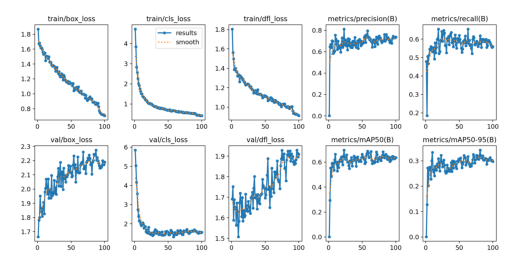

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/train/results.png")
plt.imshow(img)
plt.axis("off")


(np.float64(-0.5), np.float64(1919.5), np.float64(1919.5), np.float64(-0.5))

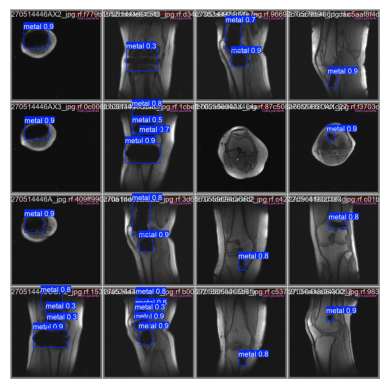

In [26]:
img = Image.open("runs/detect/train/val_batch0_pred.jpg")
plt.imshow(img)
plt.axis("off")


In [27]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")
model.val(
    data="YOLO-DATASET--1/data.yaml",
    split="test"
)


Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA H100 80GB HBM3, 81224MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 908.3±308.6 MB/s, size: 17.1 KB)
val: Scanning /content/YOLO-DATASET--1/test/labels... 178 images, 91 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 3.4Kit/s 0.1s
val: New cache created: /content/YOLO-DATASET--1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.4it/s 1.1s
                   all        178        224      0.606      0.576      0.549      0.259
Speed: 1.1ms preprocess, 2.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e0c23530e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [28]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")


In [29]:
import os
from glob import glob
import numpy as np

# Paths
test_img_dir = "YOLO-DATASET--1/test/images"
test_lbl_dir = "YOLO-DATASET--1/test/labels"

conf_thresh = 0.25

y_true = []  # ground truth: 1 = metal, 0 = no metal
y_pred = []  # prediction:   1 = metal, 0 = no metal

# Run inference
results = model.predict(
    source=test_img_dir,
    conf=conf_thresh,
    save=False,
    verbose=False
)

for res in results:
    img_name = os.path.splitext(os.path.basename(res.path))[0]
    label_file = os.path.join(test_lbl_dir, img_name + ".txt")

    # ---- Ground truth ----
    if os.path.exists(label_file) and os.path.getsize(label_file) > 0:
        y_true.append(1)   # metal present
    else:
        y_true.append(0)   # metal absent

    # ---- Prediction ----
    if res.boxes is not None and len(res.boxes) > 0:
        y_pred.append(1)   # metal detected
    else:
        y_pred.append(0)   # no metal detected


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["No Metal", "Metal"]
))


Confusion Matrix:
[[91  0]
 [ 0 87]]

Classification Report:
              precision    recall  f1-score   support

    No Metal       1.00      1.00      1.00        91
       Metal       1.00      1.00      1.00        87

    accuracy                           1.00       178
   macro avg       1.00      1.00      1.00       178
weighted avg       1.00      1.00      1.00       178



In [33]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

TN, FP, FN, TP = cm.ravel()

print("TN, FP, FN, TP =", TN, FP, FN, TP)


TN, FP, FN, TP = 91 0 0 87


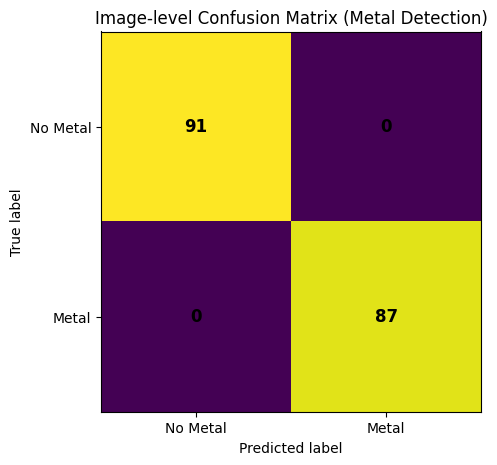

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix values
cm = np.array([[TN, FP],
               [FN, TP]])

class_names = ["No Metal", "Metal"]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm)

# Axis labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Image-level Confusion Matrix (Metal Detection)")

# Annotate each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


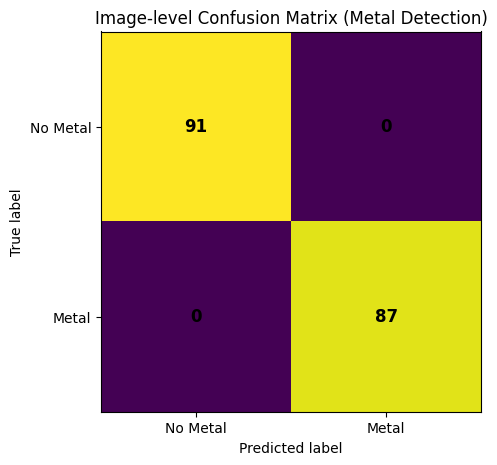

In [35]:
plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.xticks([0,1], class_names)
plt.yticks([0,1], class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Image-level Confusion Matrix (Metal Detection)")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix_metal_detection.png", dpi=300)
plt.show()


In [ ]:
model.predict(
    source="YOLO-DATASET--1/test/images",
    conf=0.25,
    save=True,
    project="qualitative_results",
    name="metal_detection",
    exist_ok=True
)


In [50]:
import os

pred_dir = "qualitative_results/metal_detection"
imgs = [f for f in os.listdir(pred_dir) if f.endswith(".jpg")]

print(f"Total saved images: {len(imgs)}")
imgs[100:170]  # show a few filenames


Total saved images: 178


['2706090041_jpg.rf.c960f7bd3e710c1bb12c8c9207c65c0b.jpg',
 '2706093747_jpg.rf.f961e531531c1e4494b75d69e171c6db.jpg',
 '270606427COR_jpg.rf.94dac114f6a02073caffb0dcd35e8327.jpg',
 '270653332AX_jpg.rf.f3ca03750f751cb16bc3ac769c508b11.jpg',
 '270657801COR2_jpg.rf.58dca153ab1e72bede7af8f85b0c802e.jpg',
 '2706095971_jpg.rf.9e34dd33e0db2043dec44a6e22927ec7.jpg',
 'lmq4_jpg.rf.2fda29507cf3e460e5c9be57ab09e030.jpg',
 'la5_jpg.rf.c7ae300e89fd01f71021d7b5bb5232e2.jpg',
 '0250435701COR_jpg.rf.10c6b7e2a5091c3925bdb27c9369cf50.jpg',
 '2706092701_jpg.rf.c1996aae996256d38b162b729a4f9475.jpg',
 'lmq6_jpg.rf.873fbad675ecc4c4a9e666c54873fa3d.jpg',
 '2706091843_jpg.rf.5a9226a42f499f0cdbbc98806530a719.jpg',
 '2706092703_jpg.rf.e0071be510d0b157e3e78e0872ecb2d7.jpg',
 '270564334AX2_jpg.rf.9553822dc93ebcd4c7879b28d7e1fd60.jpg',
 '2706095979_jpg.rf.766bcd677f75d9260e8fbe1500b0a63a.jpg',
 '2706089676_jpg.rf.74bc16bc64e3c14cd57f64dfefc9ff2a.jpg',
 '2706103232_jpg.rf.ca76e0aa7eaf94ba2dd2b1a8cf61f170.jpg',
 'vt1

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

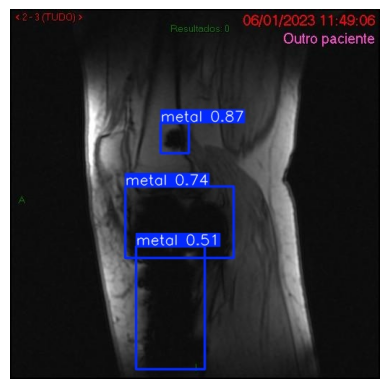

In [46]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(os.path.join(pred_dir, imgs[170]))
plt.imshow(img)
plt.axis("off")


In [53]:
selected_imgs = [
    "la11_jpg.rf.856a73c3d36763de09c65d7591b43c3e.jpg",
    "270539187SAG2_jpg.rf.ce9ce2826edb2c96f03b7662e7029030.jpg",
    "270516315AX2_jpg.rf.c9e584a9e308367fa8ff751f1b3bee96.jpg",
    "2706093748_jpg.rf.64262fbfd21cbe56e4f4c3625042675b.jpg",
    "2706090048_jpg.rf.dd130fe653faf5410aca551daa7ccd34.jpg",
    "2706093122_jpg.rf.0c65d09443168afbe1c7f1ed37adfa0a.jpg",
]


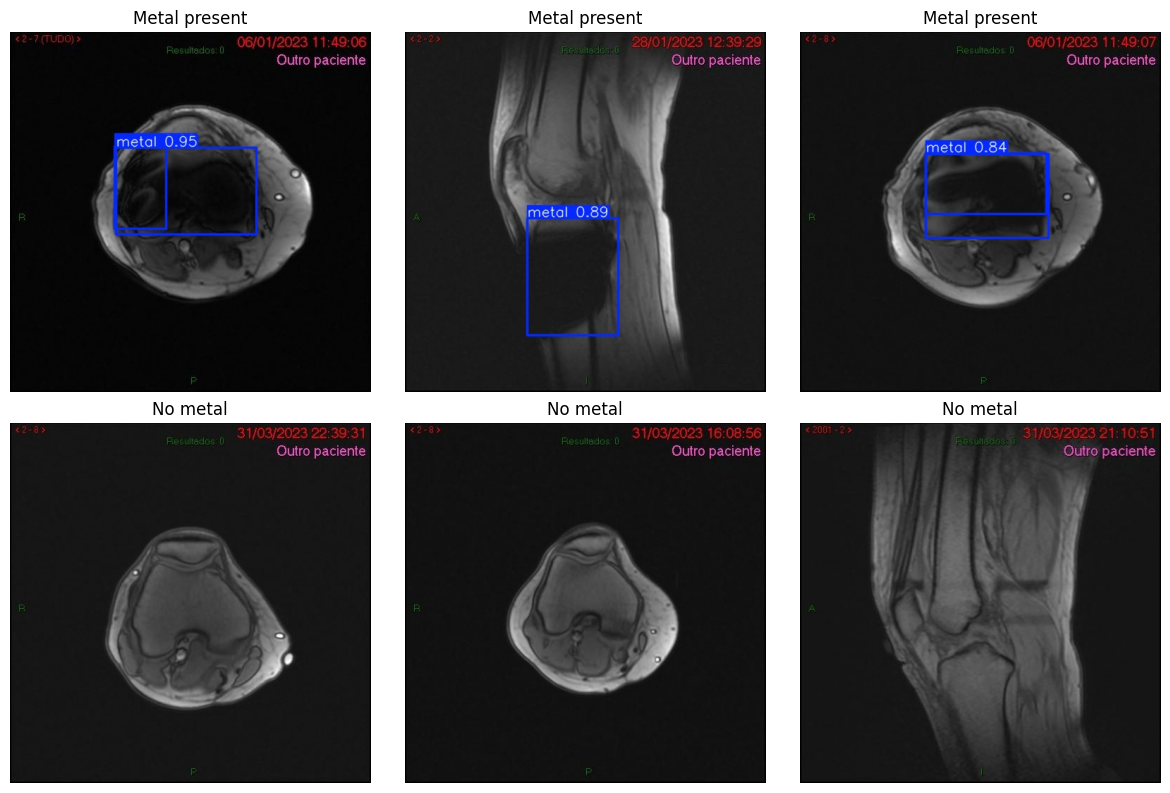

In [54]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, img_name in zip(axes.flatten(), selected_imgs):
    img = Image.open(os.path.join(pred_dir, img_name))
    ax.imshow(img)
    ax.axis("off")

axes[0,0].set_title("Metal present")
axes[0,1].set_title("Metal present")
axes[0,2].set_title("Metal present")

axes[1,0].set_title("No metal")
axes[1,1].set_title("No metal")
axes[1,2].set_title("No metal")

plt.tight_layout()
plt.savefig("qualitative_examples_metal_detection.png", dpi=300)
plt.show()
